# Monitoring Seasonal Snow-Cover Variability in the Western Everest Region Using Sentinel-2, Unsupervised Classification and Gaussian Process Gap-Filling

## Notebook 3: Gaussian Process Interpolation and Gap Validation

This notebook uses the monthly K-means snow-cover fraction produced in the previous snow-classification notebook (Notebook 2) as the input time series.

The aim of this session is to **use Gaussian Process regression to reconstruct a smooth seasonal snow-cover curve from the 12 monthly observations.** This provides both a mean prediction and an uncertainty interval, which helps show how confident the model is between the observed monthly data points.

The notebook **also includes an artificial gap validation test.** Two monthly observations are manually removed, and the Gaussian Process model is trained again using the remaining months, and the removed months are predicted to assess whether the method can reasonably fill missing observations.

## 9. Gaussian Process interpolation of monthly snow-cover fraction

Gaussian Process regression is used here to model the monthly K-means snow-cover fraction as a continuous seasonal curve. Instead of fitting one fixed equation to the data, a **Gaussian Process (GP) treats the unknown curve as a distribution of possible smooth functions.**

The model uses month number as the input variable and K-means snow-cover fraction as the output variable. An RBF kernel is used to describe the similarity between months ($l$ is the length-scale parameter):

$$
k(x, x') = \exp\left(-\frac{1}{2l^2} \| x - x' \|^2\right)
$$

This kernel assumes that **nearby months are more likely to have similar snow-cover fractions than months that are farther apart.** After training on the 12 monthly observations, the model predicts the snow-cover fraction on a denser monthly grid from January to December in 2025.

The output is a smooth GP mean prediction with a 95% uncertainty interval. **The mean curve shows the reconstructed seasonal snow-cover pattern, while the uncertainty interval shows where the model prediction is less certain between observed monthly data points.**

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install GPy

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import GPy

In [ ]:
project_dir = "/content/drive/MyDrive/GEOL0069/Final_Project"

data_dir = os.path.join(project_dir, "Data")
metadata_dir = os.path.join(data_dir, "Metadata")
figures_dir = os.path.join(project_dir, "Figures")

snow_fraction_path = os.path.join(metadata_dir, "snow_fraction_timeseries_2025.csv")

snow_fraction_timeseries = pd.read_csv(snow_fraction_path)

display(snow_fraction_timeseries)

,month,month_name,date,cloud_cover,valid_pixel_fraction,ndsi_threshold_snow_fraction,kmeans_snow_fraction
0,1,January,2025-01-31,0.002054,0.996275,0.330632,0.315693
1,2,February,2025-02-10,2.521034,0.937458,0.342165,0.334322
2,3,March,2025-03-27,0.010100,0.996253,0.377155,0.374079
3,4,April,2025-04-21,0.050823,0.996275,0.496394,0.483049
4,5,May,2025-05-08,19.816066,0.965224,0.667276,0.646826
5,6,June,2025-06-10,1.850641,0.982371,0.374713,0.365666
6,7,July,2025-07-07,12.159456,0.956667,0.355424,0.339554
7,8,August,2025-08-19,42.063248,0.475925,0.265813,0.239576
8,9,September,2025-09-05,23.067698,0.727860,0.447921,0.414957
9,10,October,2025-10-25,0.058397,0.996275,0.736586,0.620972


In [ ]:
# Input variable: month number
X = snow_fraction_timeseries["month"].values.reshape(-1, 1)

# Output variable: K-means snow-cover fraction
y = snow_fraction_timeseries["kmeans_snow_fraction"].values.reshape(-1, 1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (12, 1)
y shape: (12, 1)


In [ ]:
# Define an RBF kernel to model smooth seasonal variation
kernel = GPy.kern.RBF(input_dim=1, variance=0.05, lengthscale=2.0)

# Create GP regression model
gp_model = GPy.models.GPRegression(X, y, kernel)

# Set a small observation noise term
gp_model.Gaussian_noise.variance = 0.0005

# Optimise kernel and noise parameters
gp_model.optimize()

print(gp_model)


Name : GP regression
Objective : -4.485172412929331
Number of Parameters : 3
Number of Optimization Parameters : 3
Updates : True
Parameters:
  GP_regression.           |                 value  |  constraints  |  priors
  rbf.variance             |   0.13696412556559054  |      +ve      |        
  rbf.lengthscale          |     2.186110792335432  |      +ve      |        
  Gaussian_noise.variance  |  0.004180046048967612  |      +ve      |        


In [ ]:
# Predict on a dense monthly grid for a smooth curve
X_pred = np.linspace(1, 12, 200).reshape(-1, 1)

y_pred, y_var = gp_model.predict(X_pred)

y_pred = y_pred.reshape(-1)
y_std = np.sqrt(y_var).reshape(-1)

# 95% uncertainty interval
y_lower = y_pred - 1.96 * y_std
y_upper = y_pred + 1.96 * y_std

# Keep snow fraction within a physically meaningful range for plotting
y_lower = np.clip(y_lower, 0, 1)
y_upper = np.clip(y_upper, 0, 1)

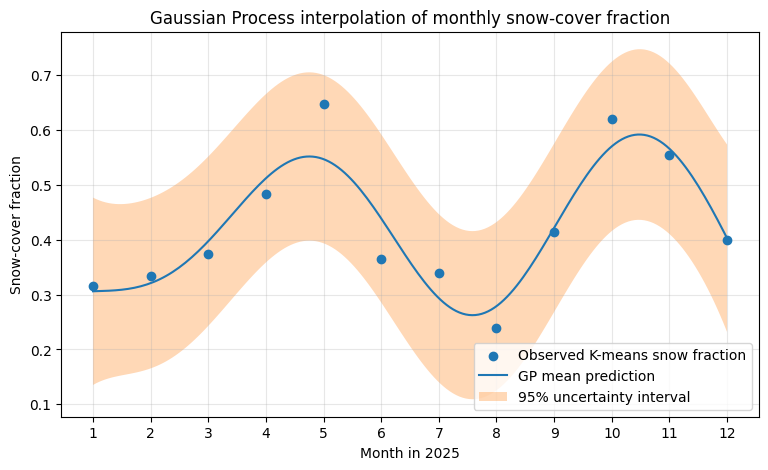

GP figure saved to:
/content/drive/MyDrive/GEOL0069/Final_Project/Figures/gp_interpolation_snow_fraction_2025.png


In [ ]:
# Save and display the GP interpolation figure
gp_figure_path = os.path.join(figures_dir, "gp_interpolation_snow_fraction_2025.png")

plt.figure(figsize=(9, 5))

plt.scatter(X, y, label="Observed K-means snow fraction",zorder=3)

plt.plot(X_pred, y_pred, label="GP mean prediction")

plt.fill_between(X_pred.reshape(-1), y_lower, y_upper, alpha=0.3, label="95% uncertainty interval")

plt.xticks(range(1, 13))
plt.xlabel("Month in 2025")
plt.ylabel("Snow-cover fraction")
plt.title("Gaussian Process interpolation of monthly snow-cover fraction")
plt.grid(True, alpha=0.3)
plt.legend()

plt.savefig(gp_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("GP figure saved to:")
print(gp_figure_path)

In [ ]:
gp_predictions = pd.DataFrame({
    "month_continuous": X_pred.reshape(-1),
    "gp_mean": y_pred,
    "gp_lower_95": y_lower,
    "gp_upper_95": y_upper
})

gp_output_path = os.path.join(metadata_dir, "gp_interpolated_snow_fraction_2025.csv")

gp_predictions.to_csv(gp_output_path, index=False)

print("GP interpolation output saved to:")
print(gp_output_path)

display(gp_predictions.head())

GP interpolation output saved to:
/content/drive/MyDrive/GEOL0069/Final_Project/Data/Metadata/gp_interpolated_snow_fraction_2025.csv


,month_continuous,gp_mean,gp_lower_95,gp_upper_95
0,1.000000,0.306042,0.135206,0.476878
1,1.055276,0.306216,0.138345,0.474088
2,1.110553,0.306393,0.141091,0.471695
3,1.165829,0.306585,0.143481,0.469689
4,1.221106,0.306807,0.145556,0.468058


## 10. Artificial gap validation

This step tests whether the Gaussian Process model can still estimate the snow cover pattern confidently with several missing months. April and October are temporarily removed from the K-means snow-cover time series and treated as artificial gaps, because they are non-adjacent months and display relatively low cloud cover in the selected monthly dataset.

A new GP model is trained using the remaining months, and the trained model is then used to predict the two held-out months. This simulates a situation where some monthly satellite observations are unavailable or not reliable enough to use.

The validation compares the GP predictions with the original K-means snow-cover fractions for April and October. **A good result would have small prediction errors and the observed values falling within the 95% uncertainty intervals.** Large errors, or observed values outside the uncertainty intervals, would suggest that the GP is less reliable for filling those gaps.

*The original time series is not changed; the two months are only held out temporarily for validation.*

In [ ]:
# Select two non-adjacent months for artificial gap validation
heldout_months = [4, 10]

# Create training and test masks
train_mask = ~snow_fraction_timeseries["month"].isin(heldout_months)
test_mask = snow_fraction_timeseries["month"].isin(heldout_months)

X_train = snow_fraction_timeseries.loc[train_mask, "month"].values.reshape(-1, 1)
y_train = snow_fraction_timeseries.loc[train_mask, "kmeans_snow_fraction"].values.reshape(-1, 1)

X_test = snow_fraction_timeseries.loc[test_mask, "month"].values.reshape(-1, 1)
y_test = snow_fraction_timeseries.loc[test_mask, "kmeans_snow_fraction"].values.reshape(-1, 1)

print("Training months:", X_train.reshape(-1))
print("Held-out months:", X_test.reshape(-1))

Training months: [ 1  2  3  5  6  7  8  9 11 12]
Held-out months: [ 4 10]


In [ ]:
# Define a new RBF kernel for the validation model
validation_kernel = GPy.kern.RBF(input_dim=1, variance=0.05, lengthscale=2.0)

# Train GP using only the remaining months
validation_gp = GPy.models.GPRegression(X_train, y_train, validation_kernel)

validation_gp.Gaussian_noise.variance = 0.0005
validation_gp.optimize()

print(validation_gp)


Name : GP regression
Objective : -2.3458266306652646
Number of Parameters : 3
Number of Optimization Parameters : 3
Updates : True
Parameters:
  GP_regression.           |                 value  |  constraints  |  priors
  rbf.variance             |   0.13014747302062138  |      +ve      |        
  rbf.lengthscale          |    2.2900165799711516  |      +ve      |        
  Gaussian_noise.variance  |  0.005522943002847373  |      +ve      |        


In [ ]:
# Predict the held-out months
y_test_pred, y_test_var = validation_gp.predict(X_test)

y_test_pred = y_test_pred.reshape(-1)
y_test_std = np.sqrt(y_test_var).reshape(-1)

y_test_lower = y_test_pred - 1.96 * y_test_std
y_test_upper = y_test_pred + 1.96 * y_test_std

# Keep bounds within 0–1 for snow-cover fraction
y_test_lower = np.clip(y_test_lower, 0, 1)
y_test_upper = np.clip(y_test_upper, 0, 1)

validation_results = pd.DataFrame({
    "month": X_test.reshape(-1),
    "observed_kmeans_snow_fraction": y_test.reshape(-1),
    "gp_predicted_snow_fraction": y_test_pred,
    "gp_lower_95": y_test_lower,
    "gp_upper_95": y_test_upper
})

validation_results["prediction_error"] = (
    validation_results["gp_predicted_snow_fraction"] -
    validation_results["observed_kmeans_snow_fraction"]
)

validation_results["absolute_error"] = validation_results["prediction_error"].abs()

validation_results["observed_within_95_interval"] = (
    (validation_results["observed_kmeans_snow_fraction"] >= validation_results["gp_lower_95"]) &
    (validation_results["observed_kmeans_snow_fraction"] <= validation_results["gp_upper_95"])
)

display(validation_results)

,month,observed_kmeans_snow_fraction,gp_predicted_snow_fraction,gp_lower_95,gp_upper_95,prediction_error,absolute_error,observed_within_95_interval
0,4,0.483049,0.527546,0.334381,0.72071,0.044496,0.044496,True
1,10,0.620972,0.506544,0.309517,0.70357,-0.114428,0.114428,True


In [ ]:
mae = validation_results["absolute_error"].mean()
rmse = np.sqrt(np.mean(validation_results["prediction_error"] ** 2))

print("Mean absolute error:", mae)
print("Root mean squared error:", rmse)

Mean absolute error: 0.07946221708471368
Root mean squared error: 0.08681514024111062


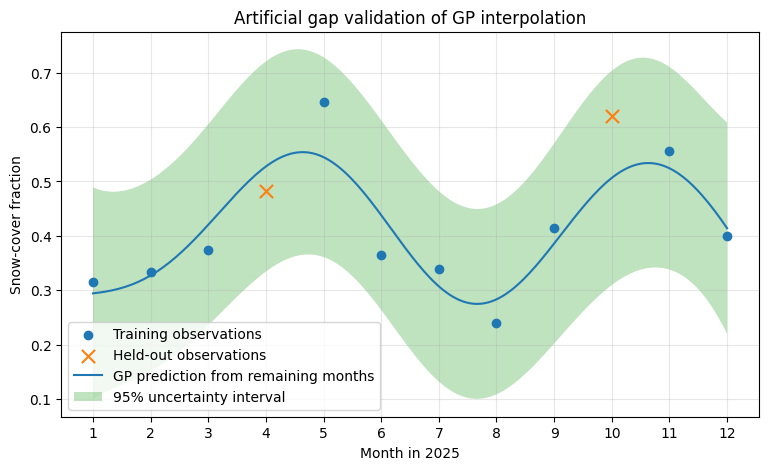

Artificial gap validation figure saved to:
/content/drive/MyDrive/GEOL0069/Final_Project/Figures/gp_artificial_gap_validation_2025.png


In [ ]:
# Save and display the artificial gap validation figure
validation_figure_path = os.path.join(figures_dir, "gp_artificial_gap_validation_2025.png")

# Predict smooth curve from the validation GP
X_pred_validation = np.linspace(1, 12, 200).reshape(-1, 1)

y_pred_validation, y_var_validation = validation_gp.predict(X_pred_validation)

y_pred_validation = y_pred_validation.reshape(-1)
y_std_validation = np.sqrt(y_var_validation).reshape(-1)

y_lower_validation = np.clip(y_pred_validation - 1.96 * y_std_validation, 0, 1)
y_upper_validation = np.clip(y_pred_validation + 1.96 * y_std_validation, 0, 1)

plt.figure(figsize=(9, 5))

# Training observations
plt.scatter(X_train, y_train, label="Training observations", zorder=3)

# Held-out observations
plt.scatter(X_test, y_test, marker="x", s=90, label="Held-out observations", zorder=4)

# GP prediction
plt.plot(X_pred_validation, y_pred_validation, label="GP prediction from remaining months")

# 95% uncertainty interval
plt.fill_between(X_pred_validation.reshape(-1), y_lower_validation, y_upper_validation, alpha=0.3, label="95% uncertainty interval")

plt.xticks(range(1, 13))
plt.xlabel("Month in 2025")
plt.ylabel("Snow-cover fraction")
plt.title("Artificial gap validation of GP interpolation")
plt.grid(True, alpha=0.3)
plt.legend()

plt.savefig(validation_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Artificial gap validation figure saved to:")
print(validation_figure_path)

In [ ]:
validation_output_path = os.path.join(metadata_dir, "gp_artificial_gap_validation_2025.csv")

validation_results.to_csv(validation_output_path, index=False)

print("Artificial gap validation results saved to:")
print(validation_output_path)

Artificial gap validation results saved to:
/content/drive/MyDrive/GEOL0069/Final_Project/Data/Metadata/gp_artificial_gap_validation_2025.csv
